In [2]:
from torch import nn
import torch
from torchvision import datasets
from torchvision import transforms
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt
from helper_functions import accuracy_fn
from tqdm.auto import tqdm
from torch.utils.data import DataLoader


c:\Users\ROG\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
train_data = datasets.MNIST(
    root = 'Mnist_dataset',
    train = True,
    transform = ToTensor(),
    download = False,
    target_transform = None
)

In [4]:
test_data = datasets.MNIST(
    root = 'Mnist_dataset',
    train = False,
    transform = ToTensor(),
    download = False,
    target_transform = None
)

In [5]:
len(train_data),len(test_data)

(60000, 10000)

torch.Size([1, 28, 28])

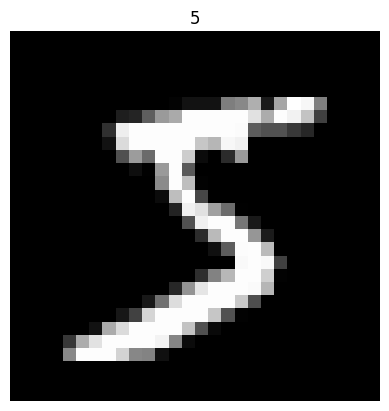

In [6]:
image , label = train_data[0]
plt.imshow(image.squeeze(),cmap = 'gray')
plt.title(label=label)
plt.axis(False)
image.shape

In [7]:
class_names = train_data.classes
class_names

['0 - zero',
 '1 - one',
 '2 - two',
 '3 - three',
 '4 - four',
 '5 - five',
 '6 - six',
 '7 - seven',
 '8 - eight',
 '9 - nine']

In [8]:
class_to_idx = train_data.class_to_idx
class_to_idx

{'0 - zero': 0,
 '1 - one': 1,
 '2 - two': 2,
 '3 - three': 3,
 '4 - four': 4,
 '5 - five': 5,
 '6 - six': 6,
 '7 - seven': 7,
 '8 - eight': 8,
 '9 - nine': 9}

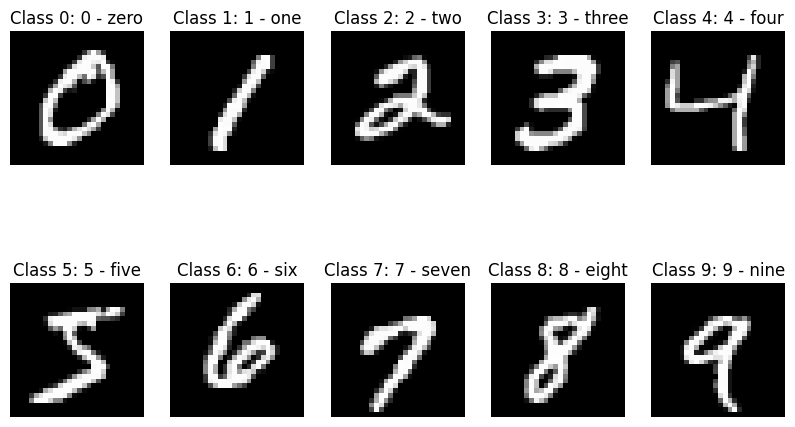

In [9]:
fig = plt.figure(figsize=(10, 6))

for class_idx in range(10):

    # Find the first image belonging to this class
    for image, label in train_data:
        if label == class_idx:
            fig.add_subplot(2, 5, class_idx + 1)

            plt.imshow(image.squeeze(), cmap="gray")
            plt.title(f"Class {class_idx}: {class_names[class_idx]}")
            plt.axis("off")

            break

In [10]:
train_data

Dataset MNIST
    Number of datapoints: 60000
    Root location: Mnist_dataset
    Split: Train
    StandardTransform
Transform: ToTensor()

### Turning dataset into python iterable using dataloader of bacth size 32

In [11]:
BATCH_SIZE = 32

train_dataloader = DataLoader(
    dataset = train_data,
    batch_size = BATCH_SIZE,
    shuffle = True
)

test_dataloader = DataLoader(
    dataset = test_data,
    batch_size = BATCH_SIZE,
    shuffle = False
)



## neural network architecture

In [12]:
class MnistV1(nn.Module):
    def __init__(self,
                 input_shape : int,
                 hidden_layer : int,
                 output_shape : int):
        super().__init__()

        self.layer_stack = nn.Sequential(
            nn.Flatten(),
            
            nn.Linear(in_features = input_shape,
                      out_features = hidden_layer),
            nn.ReLU(),

            nn.Linear(in_features = hidden_layer,
                      out_features = hidden_layer),
            nn.ReLU(),


            nn.Linear(in_features = hidden_layer,
                      out_features = output_shape)
            
      

            
        )
    def forward(self,x):
        return self.layer_stack(x)

In [13]:
model = MnistV1(
    input_shape = 784,
    hidden_layer = 64,
    output_shape = len(class_names)
)

In [14]:
model

MnistV1(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=64, bias=True)
    (2): ReLU()
    (3): Linear(in_features=64, out_features=64, bias=True)
    (4): ReLU()
    (5): Linear(in_features=64, out_features=10, bias=True)
  )
)

### Setup loss function(crossEntropyloss) and optimizer

In [15]:
loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(params = model.parameters(),
                            lr = 0.0001)

In [16]:
torch.manual_seed(42)

epoch = 10

for epoch in tqdm(range(epoch)):

    train_loss = 0

    for batch , (image,label) in enumerate(train_dataloader):

        
        model.train()

        y_pred = model(image)

        loss = loss_fn(y_pred,label)
        train_loss += loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    train_loss /= len(train_dataloader)

    test_loss , test_acc = 0 , 0

    model.eval()

    with torch.inference_mode():

        for test_image , test_label in test_dataloader:

            test_pred = model(test_image)

            test_loss += loss_fn(test_pred,test_label)

            test_acc += accuracy_fn(y_true = test_label,
                                    y_pred = test_pred.argmax(dim=1))


        test_loss /= len(test_dataloader)
        test_acc /= len(test_dataloader)

    print(f"\nTrain loss: {train_loss :.4f} | Test loss: {test_loss :.4f}, Test acc: {test_acc :.4f}")
    


 10%|█         | 1/10 [00:06<00:57,  6.38s/it]


Train loss: 0.7957 | Test loss: 0.3566, Test acc: 89.9760


 20%|██        | 2/10 [00:13<00:52,  6.55s/it]


Train loss: 0.3279 | Test loss: 0.2876, Test acc: 91.6134


 30%|███       | 3/10 [00:20<00:47,  6.73s/it]

...


Train loss: 0.1741 | Test loss: 0.1669, Test acc: 94.9281


 90%|█████████ | 9/10 [01:01<00:06,  6.73s/it]


Train loss: 0.1622 | Test loss: 0.1570, Test acc: 95.2776


100%|██████████| 10/10 [01:07<00:00,  6.79s/it]


Train loss: 0.1517 | Test loss: 0.1536, Test acc: 95.4473


In [20]:
from pathlib import Path

MODEL_PATH = Path("Mnist_final_model")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

#model name
model_name = "Mnist_number_detection.pth"

#model save in path /model name
model_save_path = MODEL_PATH / model_name

# f - file path
# obj - object to save state dict of model is preferred to save the model weights and biases

torch.save(obj=model.state_dict(), f=model_save_path)




In [18]:
import tkinter as tk
from PIL import Image, ImageDraw
import torch
import numpy as np
from scipy import ndimage

WIDTH = 280
HEIGHT = 280
BRUSH_SIZE = 20

root = tk.Tk()
root.title("MNIST Digit Predictor")


# Create black canvas
canvas = tk.Canvas(
    root,
    width=WIDTH,
    height=HEIGHT,
    bg="black"
)

canvas.pack()


# PIL image to store what we draw
image = Image.new("L", (WIDTH, HEIGHT), 0)
draw = ImageDraw.Draw(image)


# -------------------------
# Drawing
# -------------------------

def draw_digit(event):

    x = event.x
    y = event.y

    canvas.create_oval(
        x - BRUSH_SIZE // 2,
        y - BRUSH_SIZE // 2,
        x + BRUSH_SIZE // 2,
        y + BRUSH_SIZE // 2,
        fill="white",
        outline="white"
    )

    draw.ellipse(
        [
            x - BRUSH_SIZE // 2,
            y - BRUSH_SIZE // 2,
            x + BRUSH_SIZE // 2,
            y + BRUSH_SIZE // 2
        ],
        fill=255
    )


canvas.bind("<B1-Motion>", draw_digit)


# -------------------------
# MNIST-style preprocessing helpers
# -------------------------

def center_by_mass(img_array, size=28):
    """
    Shift the digit so its center of mass sits at the center of the frame.
    This is what the real MNIST dataset does — NOT bounding-box centering.
    """
    cy, cx = ndimage.center_of_mass(img_array)
    rows, cols = img_array.shape
    shift_y = np.round(size / 2 - cy).astype(int)
    shift_x = np.round(size / 2 - cx).astype(int)
    shifted = ndimage.shift(img_array, shift=[shift_y, shift_x], cval=0)
    return shifted


def preprocess_for_mnist(pil_img):
    """
    Full MNIST-matching pipeline:
    1. Crop to bounding box
    2. Pad to square with margin (20x20 digit inside 28x28 frame, MNIST convention)
    3. Resize with high-quality resampling
    4. Center by mass of pixel intensity
    """
    bbox = pil_img.getbbox()
    if bbox is None:
        return None

    # Crop tightly to the drawn digit
    cropped = pil_img.crop(bbox)

    # Resize so the LONGER side becomes 20px (MNIST digits occupy ~20x20
    # inside the 28x28 canvas, with a few px margin on each side)
    w, h = cropped.size
    if w > h:
        new_w = 20
        new_h = max(1, round(h * (20 / w)))
    else:
        new_h = 20
        new_w = max(1, round(w * (20 / h)))

    resized = cropped.resize((new_w, new_h), Image.LANCZOS)

    # Paste onto a 28x28 black canvas, centered
    canvas28 = Image.new("L", (28, 28), 0)
    paste_x = (28 - new_w) // 2
    paste_y = (28 - new_h) // 2
    canvas28.paste(resized, (paste_x, paste_y))

    # Convert to numpy, then re-center by center of mass (like the real
    # MNIST preprocessing pipeline does)
    arr = np.array(canvas28, dtype=np.float32)

    if arr.sum() > 0:
        arr = center_by_mass(arr, size=28)

    return arr


# -------------------------
# Prediction
# -------------------------

def predict():

    img = image.copy()

    arr = preprocess_for_mnist(img)

    if arr is None:
        result_label.config(text="Draw a digit first!")
        return

    # Normalize to [0, 1] same as ToTensor() during training
    arr = arr / 255.0

    img_tensor = torch.tensor(arr, dtype=torch.float32).reshape(1, 1, 28, 28)

    model.eval()
    with torch.inference_mode():
        prediction = model(img_tensor)

    probs = torch.softmax(prediction, dim=1)
    predicted_class = prediction.argmax(dim=1).item()
    confidence = probs[0, predicted_class].item() * 100

    result_label.config(
        text=f"Prediction: {predicted_class}  ({confidence:.1f}%)"
    )


# -------------------------
# Clear
# -------------------------

def clear():

    canvas.delete("all")

    draw.rectangle(
        [0, 0, WIDTH, HEIGHT],
        fill=0
    )

    result_label.config(
        text="Prediction: "
    )


# -------------------------
# Buttons
# -------------------------

predict_button = tk.Button(
    root,
    text="Predict",
    command=predict
)

predict_button.pack()


clear_button = tk.Button(
    root,
    text="Clear",
    command=clear
)

clear_button.pack()


result_label = tk.Label(
    root,
    text="Prediction: ",
    font=("Arial", 20)
)

result_label.pack()


root.mainloop()

In [19]:
import tkinter as tk
from PIL import Image, ImageDraw
import torch


# -------------------------
# Setup
# -------------------------

WIDTH = 280
HEIGHT = 280
BRUSH_SIZE = 20

root = tk.Tk()
root.title("MNIST Digit Predictor")


# Create black canvas
canvas = tk.Canvas(
    root,
    width=WIDTH,
    height=HEIGHT,
    bg="black"
)

canvas.pack()


# PIL image to store what we draw
image = Image.new("L", (WIDTH, HEIGHT), 0)
draw = ImageDraw.Draw(image)


# -------------------------
# Drawing
# -------------------------

def draw_digit(event):

    x = event.x
    y = event.y

    # Draw on Tkinter canvas
    canvas.create_oval(
        x - BRUSH_SIZE // 2,
        y - BRUSH_SIZE // 2,
        x + BRUSH_SIZE // 2,
        y + BRUSH_SIZE // 2,
        fill="white",
        outline="white"
    )

    # Draw on PIL image
    draw.ellipse(
        [
            x - BRUSH_SIZE // 2,
            y - BRUSH_SIZE // 2,
            x + BRUSH_SIZE // 2,
            y + BRUSH_SIZE // 2
        ],
        fill=255
    )


canvas.bind("<B1-Motion>", draw_digit)


# -------------------------
# Prediction
# -------------------------

def predict():

    # Get the PIL image
    img = image.copy()

    # Find bounding box around the digit
    bbox = img.getbbox()

    if bbox is None:
        result_label.config(text="Draw a digit first!")
        return

    # Crop the digit
    img = img.crop(bbox)

    # Make it square
    width, height = img.size
    size = max(width, height)

    square = Image.new("L", (size, size), 0)

    x = (size - width) // 2
    y = (size - height) // 2

    square.paste(img, (x, y))

    # Resize to MNIST size
    img = square.resize((28, 28))

    # Convert to tensor
    img_tensor = torch.tensor(
        list(img.getdata()),
        dtype=torch.float32
    ).reshape(1, 1, 28, 28)

    # Normalize
    img_tensor /= 255.0

    # Predict
    model.eval()

    with torch.inference_mode():
        prediction = model(img_tensor)

    predicted_class = prediction.argmax(dim=1).item()

    result_label.config(
        text=f"Prediction: {predicted_class}"
    )

# -------------------------
# Clear
# -------------------------

def clear():

    canvas.delete("all")

    draw.rectangle(
        [0, 0, WIDTH, HEIGHT],
        fill=0
    )

    result_label.config(
        text="Prediction: "
    )


# -------------------------
# Buttons
# -------------------------

predict_button = tk.Button(
    root,
    text="Predict",
    command=predict
)

predict_button.pack()


clear_button = tk.Button(
    root,
    text="Clear",
    command=clear
)

clear_button.pack()


result_label = tk.Label(
    root,
    text="Prediction: ",
    font=("Arial", 20)
)

result_label.pack()


root.mainloop()